In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import scanpy as sc
from itertools import combinations
from scipy.optimize import linear_sum_assignment
from scipy.stats import pearsonr

sys.path.append('../../..')
import sherlock as slk

/opt/conda/envs/perturb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_RUNS      = 20
RESULTS_DIR = "results/reproducibility_gbm"

# ── change this to explore different cluster granularities ────────────────────
N_CLUSTERS  = 5   # number of clusters for maxclust (used in the main analysis below)
# ─────────────────────────────────────────────────────────────────────────────

# Exact params from gbm_run.ipynb
SHERLOCK_KWARGS = dict(
    batch_size     = 4096,
    num_workers    = 0,
    num_epochs     = 300,
    use_conditions = True,
    validate_every = 50,
    l0_lambda      = 40.0,
    ce_lambda      = 1e2,
    lr             = 1e-2,
    patience       = 500,
    rho_init       = True,
    ntc_lambda     = 1.0,
    cov_lambda     = 1e-1,
    # prior_cond_ridge = 1e-1,
)

os.makedirs(f"{RESULTS_DIR}/figures",  exist_ok=True)
os.makedirs(f"{RESULTS_DIR}/matrices", exist_ok=True)
print(f"Device: {DEVICE}  Results: {RESULTS_DIR}")

Device: cuda  Results: results/reproducibility_gbm


## Data loading

In [4]:
slk.configs.reset_config()
slk.configs.set_config('untreated_label', '0.0')

data = sc.read_h5ad("../../datasets/gbm/filtered_gbm_crispri_crop.h5ad")
data.obs.dose = data.obs.dose.astype(str)
slk.pp.slk_prepare_data(
    data, pert_key="gene_id", ntc_label="NTC",
    treatment_key='dose', untreated_label='0.0', inplace=True, force=True
)
# data = data[data.obs.dose == '0.0'].copy()
# slk.pp.slk_prepare_data(
#     data, pert_key="gene_id", ntc_label="NTC",
#     inplace=True, force=True
# )

p_key     = slk.configs.get_config('pert_key')
NTC       = slk.configs.get_config('ntc_label')
c_key     = slk.configs.get_config('treatment_key')
c_ntc_key = slk.configs.get_config('untreated_label')

print(f"Cells: {data.n_obs}   Genes: {data.n_vars}")
print(f"Perturbations (non-NTC): {data.obs[p_key].nunique() - 1}")
print(f"Conditions: {sorted(data.obs[c_key].unique())}")

Cells: 21429   Genes: 1758
Perturbations (non-NTC): 100
Conditions: ['0.0', '0.25', '0.5', '1.0']


In [5]:
slk.pp.treat_effect(
    data,
    label_col='pert',
    control_label='NTC',
    method='perturbseq',
    inplace=True,
    key='treat_effect',
)

100%|██████████| 100/100 [00:01<00:00, 73.85it/s]


## Part 1 — Reproducibility loop (train once, save matrices)

Train Sherlock `N_RUNS` times with the same hyper-parameters as `gbm_run.ipynb`.
After each run the **rho_corr** and **W** matrices are saved to
`{RESULTS_DIR}/matrices/run_{k}.npz` so that all downstream clustering analysis
can be repeated without retraining.

> **Tip**: skip this section if the matrices already exist and jump straight to
> *Part 2 — Load saved matrices*.

In [6]:
use_rerun = True

for run in range(N_RUNS):
    out_path = f"{RESULTS_DIR}/matrices/run_{run}.npz"
    if os.path.exists(out_path) and use_rerun:
        print(f"Run {run+1}: matrices already saved, skipping training.")
        continue

    print(f"\n{'='*50}\nGBM run {run + 1}/{N_RUNS}\n{'='*50}")
    out   = slk.tl.run(data, device=DEVICE, seed=run, **SHERLOCK_KWARGS)
    model = out['model']

    slk.tl.eval(model, data, obsm_key='z', uns_key='results', device=DEVICE)
    eval_res = data.uns['results']

    rho_corr  = np.asarray(eval_res['rho_corr'],  dtype=float)
    z_corr    = np.asarray(eval_res['z_corr'],    dtype=float)
    rho_perts = np.asarray(eval_res['rho_perts'])
    W         = np.asarray(eval_res['W'])

    # Save matrices so clustering can be explored without retraining
    np.save(f"{RESULTS_DIR}/matrices/run_{run}_rho_corr.npy", rho_corr)
    np.save(f"{RESULTS_DIR}/matrices/run_{run}_z_corr.npy",   z_corr)
    np.save(f"{RESULTS_DIR}/matrices/run_{run}_W.npy",        W)
    np.savetxt(f"{RESULTS_DIR}/matrices/run_{run}_perts.txt", rho_perts, fmt='%s')
    # sentinel file so the skip-check above works
    np.savez(out_path)

    print(f"  Saved to {out_path}")

print("\nTraining complete (or all matrices already saved).")


GBM run 1/20
Training VAE on cuda …


Epochs: 100%|██████████| 300/300 [04:10<00:00,  1.20it/s, ATE=0.1543, CE=0.0965, ELBO=1346.7607, KLw=1.00, R2_ntc=0.6551, R2_p=0.6423, acc=0.968, pi25=0.02, pi99=0.99, tau=0.300]


  Saved to results/reproducibility_gbm/matrices/run_0.npz

GBM run 2/20
Training VAE on cuda …


Epochs: 100%|██████████| 300/300 [04:07<00:00,  1.21it/s, ATE=0.1554, CE=0.0931, ELBO=1347.8143, KLw=1.00, R2_ntc=0.6332, R2_p=0.6382, acc=0.971, pi25=0.02, pi99=1.00, tau=0.300]


  Saved to results/reproducibility_gbm/matrices/run_1.npz

GBM run 3/20
Training VAE on cuda …


...

  Saved to results/reproducibility_gbm/matrices/run_17.npz

GBM run 19/20
Training VAE on cuda …


Epochs: 100%|██████████| 300/300 [04:00<00:00,  1.25it/s, ATE=0.1642, CE=0.1032, ELBO=1342.0604, KLw=1.00, R2_ntc=0.6735, R2_p=0.6411, acc=0.968, pi25=0.02, pi99=0.99, tau=0.300]


  Saved to results/reproducibility_gbm/matrices/run_18.npz

GBM run 20/20
Training VAE on cuda …


Epochs: 100%|██████████| 300/300 [04:01<00:00,  1.24it/s, ATE=0.1512, CE=0.1134, ELBO=1346.1432, KLw=1.00, R2_ntc=0.6548, R2_p=0.6479, acc=0.964, pi25=0.02, pi99=1.00, tau=0.300]


  Saved to results/reproducibility_gbm/matrices/run_19.npz

Training complete (or all matrices already saved).


## Part 2 — Load saved matrices

Re-entry point: run cells from here if the matrices were already saved in a previous
session (data loading cells above still need to be executed for `cluster_rho`).

In [27]:
run_results = []
for run in range(N_RUNS):
    rho_corr  = np.load(f"{RESULTS_DIR}/matrices/run_{run}_rho_corr.npy")
    z_corr    = np.load(f"{RESULTS_DIR}/matrices/run_{run}_z_corr.npy")
    W         = np.load(f"{RESULTS_DIR}/matrices/run_{run}_W.npy")
    rho_perts = np.loadtxt(f"{RESULTS_DIR}/matrices/run_{run}_perts.txt", dtype=str)
    run_results.append({
        'run':      run,
        'rho_corr': rho_corr,
        'z_corr':   z_corr,
        'W':        W,
        'rho_perts': rho_perts,
    })
    print(f"Run {run+1}: rho_corr {rho_corr.shape}  W {W.shape}  perts {len(rho_perts)}")

# Perturbation names (consistent across runs — alphabetically sorted by the dataset)
all_perts = sorted(run_results[0]['rho_perts'].tolist())
print(f"\n{len(all_perts)} perturbations: {all_perts[:5]} … {all_perts[-5:]}")

Run 1: rho_corr (100, 100)  W (100, 16)  perts 100
Run 2: rho_corr (100, 100)  W (100, 16)  perts 100
Run 3: rho_corr (100, 100)  W (100, 16)  perts 100
Run 4: rho_corr (100, 100)  W (100, 16)  perts 100
Run 5: rho_corr (100, 100)  W (100, 16)  perts 100
Run 6: rho_corr (100, 100)  W (100, 16)  perts 100
Run 7: rho_corr (100, 100)  W (100, 16)  perts 100
Run 8: rho_corr (100, 100)  W (100, 16)  perts 100
Run 9: rho_corr (100, 100)  W (100, 16)  perts 100
Run 10: rho_corr (100, 100)  W (100, 16)  perts 100
Run 11: rho_corr (100, 100)  W (100, 16)  perts 100
Run 12: rho_corr (100, 100)  W (100, 16)  perts 100
Run 13: rho_corr (100, 100)  W (100, 16)  perts 100
Run 14: rho_corr (100, 100)  W (100, 16)  perts 100
Run 15: rho_corr (100, 100)  W (100, 16)  perts 100
Run 16: rho_corr (100, 100)  W (100, 16)  perts 100
Run 17: rho_corr (100, 100)  W (100, 16)  perts 100
Run 18: rho_corr (100, 100)  W (100, 16)  perts 100
Run 19: rho_corr (100, 100)  W (100, 16)  perts 100
Run 20: rho_corr (100

## Helper: group alignment (Hungarian matching)

Integer cluster labels are arbitrary across runs.  
`align_groups_to_reference` Hungarian-matches a target run's group labels to a
reference run's labels by maximising shared membership, then applies that mapping so
both runs live in the same label space.

In [28]:
def align_groups_to_reference(ref_ng, tgt_ng):
    """Return dict: tgt_group_int -> ref_group_int via Hungarian matching."""
    common = set(ref_ng.index) & set(tgt_ng.index)
    if not common:
        return {}
    ref_labels = sorted(ref_ng['group'].unique())
    tgt_labels = sorted(tgt_ng['group'].unique())
    C = np.zeros((len(ref_labels), len(tgt_labels)), dtype=int)
    for gene in common:
        ri = ref_labels.index(ref_ng.loc[gene, 'group'])
        ti = tgt_labels.index(tgt_ng.loc[gene, 'group'])
        C[ri, ti] += 1
    row_ind, col_ind = linear_sum_assignment(C.max() - C)
    mapping = {tgt_labels[j]: ref_labels[i] for i, j in zip(row_ind, col_ind)}
    # Extra target groups (when tgt has more groups than ref) -> majority vote
    for tl in tgt_labels:
        if tl not in mapping:
            genes_in_tl = [g for g in tgt_ng.index if tgt_ng.loc[g, 'group'] == tl and g in common]
            if genes_in_tl:
                vote = {}
                for g in genes_in_tl:
                    rg = ref_ng.loc[g, 'group']
                    vote[rg] = vote.get(rg, 0) + 1
                mapping[tl] = max(vote, key=vote.get)
    return mapping


def cluster_all_runs(run_results, n_clusters, all_perts):
    """
    Cluster every run's rho_corr with maxclust=n_clusters.
    Returns a list of dicts adding 'groups' and 'named_groups' keys.
    """
    clustered = []
    for rr in run_results:
        groups       = slk.tl.cluster_rho(
            data, t=n_clusters, rho_corr=rr['z_corr'],
            criterion='maxclust', show=False,
        )
        named_groups = slk.tl.group2name(groups, list(rr['rho_perts']))
        clustered.append({**rr, 'groups': groups, 'named_groups': named_groups})
    return clustered


def compute_confidence(clustered_runs, all_perts):
    """
    For each perturbation (by name), compute what fraction of runs it was
    assigned to each reference group (run 1's labels after Hungarian alignment).
    Returns confidence_df sorted by modal group then descending confidence.
    """
    ref_ng     = clustered_runs[0]['named_groups']
    ref_groups = sorted(ref_ng['group'].unique())
    n_runs     = len(clustered_runs)

    aligned = {p: [] for p in all_perts}
    for rr in clustered_runs:
        mapping = ({g: g for g in ref_groups} if rr['run'] == 0
                   else align_groups_to_reference(ref_ng, rr['named_groups']))
        ng = rr['named_groups']
        for p in all_perts:
            if p in ng.index:
                aligned[p].append(mapping.get(ng.loc[p, 'group'], -1))
            else:
                aligned[p].append(-1)

    group_cols = [f"Group {g}" for g in ref_groups]
    rows = []
    for p in all_perts:
        asn  = aligned[p]
        row  = {f"Group {g}": asn.count(g) / n_runs for g in ref_groups}
        row['modal_group'] = f"Group {max(ref_groups, key=lambda g: asn.count(g))}"
        row['max_conf']    = max(asn.count(g) for g in ref_groups) / n_runs
        row['unassigned']  = asn.count(-1) / n_runs
        rows.append({'perturbation': p, **row})

    df = pd.DataFrame(rows).set_index('perturbation')
    return df.sort_values(['modal_group', 'max_conf'], ascending=[True, False]), group_cols


def compute_pairwise_similarity(clustered_runs, all_perts):
    """Compute W, rho_corr, Jaccard (raw & aligned) for every pair of runs."""

    def _jaccard(labels_i, labels_j):
        n      = len(labels_i)
        same_i = labels_i[:, None] == labels_i[None, :]
        same_j = labels_j[:, None] == labels_j[None, :]
        triu   = np.triu_indices(n, k=1)
        a, b   = same_i[triu], same_j[triu]
        union  = int((a | b).sum())
        return int((a & b).sum()) / union if union > 0 else np.nan

    n_runs = len(clustered_runs)
    pairs  = list(combinations(range(n_runs), 2))
    w_corrs, cov_corrs, jac_raw, jac_aln = [], [], [], []

    for i, j in pairs:
        ri, rj = clustered_runs[i], clustered_runs[j]

        Ci = ri['W'] @ ri['W'].T
        Cj = rj['W'] @ rj['W'].T
        triu = np.triu_indices(Ci.shape[0], k=1)
        w_corrs.append(pearsonr(Ci[triu], Cj[triu])[0])

        fi, fj = ri['z_corr'][triu], rj['z_corr'][triu]
        valid  = np.isfinite(fi) & np.isfinite(fj)
        cov_corrs.append(pearsonr(fi[valid], fj[valid])[0])

        jac_raw.append(_jaccard(ri['groups'].astype(object), rj['groups'].astype(object)))

        ng_i, ng_j   = ri['named_groups'], rj['named_groups']
        common       = [p for p in all_perts if p in ng_i.index and p in ng_j.index]
        mapping_ij   = align_groups_to_reference(ng_i, ng_j)
        mp_i = np.array([ng_i.loc[p, 'group'] for p in common], dtype=object)
        mp_j = np.array([mapping_ij.get(ng_j.loc[p, 'group'], -1) for p in common], dtype=object)
        valid_mask = mp_j != -1
        jac_aln.append(_jaccard(mp_i[valid_mask], mp_j[valid_mask]))

    return pairs, w_corrs, cov_corrs, jac_raw, jac_aln

## Part 3 — Cluster-count stability sweep

For each candidate number of clusters (2 … `SWEEP_MAX`) apply `maxclust` clustering
to every run's saved `rho_corr`, then compute:
- **Mean pairwise Jaccard (aligned)** across all run-pairs — higher = more consistent groupings
- **Mean max-confidence** per perturbation — higher = each pert stably belongs to one group

Use this plot to choose `N_CLUSTERS` above.

In [29]:
SWEEP_MIN = 2
SWEEP_MAX = 14

sweep_results = []
for k in range(SWEEP_MIN, SWEEP_MAX + 1):
    clustered = cluster_all_runs(run_results, k, all_perts)
    _, w_c, cov_c, jac_r, jac_a = compute_pairwise_similarity(clustered, all_perts)
    conf_df, _                   = compute_confidence(clustered, all_perts)
    sweep_results.append({
        'n_clusters':        k,
        'jaccard_raw_mean':  np.nanmean(jac_r),
        'jaccard_aln_mean':  np.nanmean(jac_a),
        'jaccard_aln_std':   np.nanstd(jac_a),
        'mean_max_conf':     conf_df['max_conf'].mean(),
        'frac_stable_08':    (conf_df['max_conf'] >= 0.8).mean(),
        'w_corr_mean':       np.mean(w_c),
        'rho_corr_mean':     np.mean(cov_c),
    })
    print(f"  k={k:2d}  jac_aln={np.nanmean(jac_a):.3f}  mean_conf={conf_df['max_conf'].mean():.3f}  "
          f"stable(≥0.8)={( conf_df['max_conf'] >= 0.8).mean():.2f}")

sweep_df = pd.DataFrame(sweep_results).set_index('n_clusters')
print("\n", sweep_df.round(3).to_string())

  k= 2  jac_aln=0.394  mean_conf=0.739  stable(≥0.8)=0.40
  k= 3  jac_aln=0.269  mean_conf=0.562  stable(≥0.8)=0.07
  k= 4  jac_aln=0.210  mean_conf=0.518  stable(≥0.8)=0.08
  k= 5  jac_aln=0.172  mean_conf=0.460  stable(≥0.8)=0.02
  k= 6  jac_aln=0.152  mean_conf=0.433  stable(≥0.8)=0.01
  k= 7  jac_aln=0.133  mean_conf=0.415  stable(≥0.8)=0.02
  k= 8  jac_aln=0.120  mean_conf=0.400  stable(≥0.8)=0.01
  k= 9  jac_aln=0.111  mean_conf=0.406  stable(≥0.8)=0.00
  k=10  jac_aln=0.105  mean_conf=0.403  stable(≥0.8)=0.02
  k=11  jac_aln=0.095  mean_conf=0.387  stable(≥0.8)=0.00
  k=12  jac_aln=0.091  mean_conf=0.390  stable(≥0.8)=0.00
  k=13  jac_aln=0.086  mean_conf=0.386  stable(≥0.8)=0.00
  k=14  jac_aln=0.082  mean_conf=0.385  stable(≥0.8)=0.01

             jaccard_raw_mean  jaccard_aln_mean  jaccard_aln_std  mean_max_conf  frac_stable_08  w_corr_mean  rho_corr_mean
n_clusters                                                                                                               

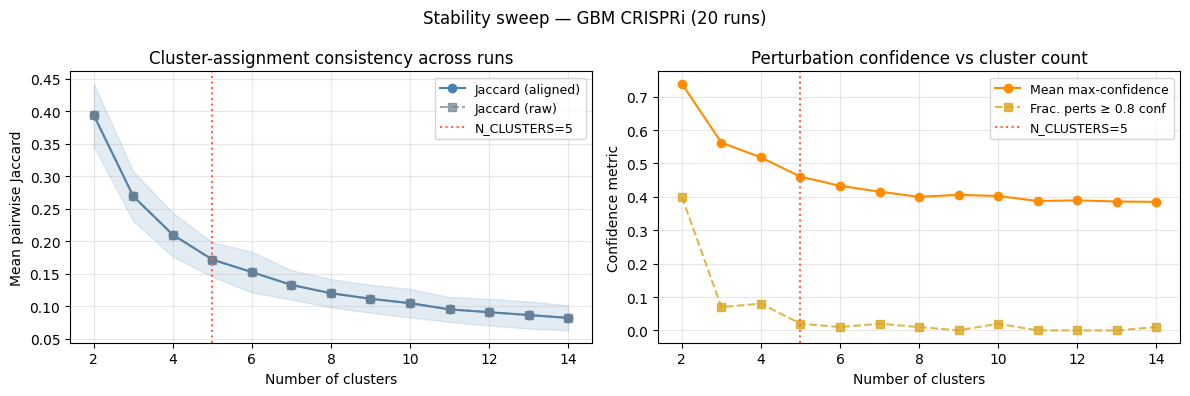

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

ks = sweep_df.index.values

ax = axes[0]
ax.plot(ks, sweep_df['jaccard_aln_mean'], 'o-', color='steelblue', label='Jaccard (aligned)')
ax.fill_between(
    ks,
    sweep_df['jaccard_aln_mean'] - sweep_df['jaccard_aln_std'],
    sweep_df['jaccard_aln_mean'] + sweep_df['jaccard_aln_std'],
    alpha=0.15, color='steelblue',
)
ax.plot(ks, sweep_df['jaccard_raw_mean'], 's--', color='slategray', label='Jaccard (raw)', alpha=0.7)
ax.axvline(N_CLUSTERS, color='tomato', linestyle=':', linewidth=1.5, label=f'N_CLUSTERS={N_CLUSTERS}')
ax.set_xlabel('Number of clusters')
ax.set_ylabel('Mean pairwise Jaccard')
ax.set_title('Cluster-assignment consistency across runs')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(ks, sweep_df['mean_max_conf'],  'o-',  color='darkorange', label='Mean max-confidence')
ax.plot(ks, sweep_df['frac_stable_08'], 's--', color='goldenrod',  label='Frac. perts ≥ 0.8 conf', alpha=0.8)
ax.axvline(N_CLUSTERS, color='tomato', linestyle=':', linewidth=1.5, label=f'N_CLUSTERS={N_CLUSTERS}')
ax.set_xlabel('Number of clusters')
ax.set_ylabel('Confidence metric')
ax.set_title('Perturbation confidence vs cluster count')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

fig.suptitle(f'Stability sweep — GBM CRISPRi ({N_RUNS} runs)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/stability_sweep.png', bbox_inches='tight', dpi=150)
plt.show()

## Part 4 — Main analysis for chosen N_CLUSTERS

Cluster all runs with the `N_CLUSTERS` value set at the top of the notebook, then
compute confidence, co-membership, and pairwise similarity.

In [33]:
clustered_runs = cluster_all_runs(run_results, N_CLUSTERS, all_perts)

print(f"Clustering with N_CLUSTERS={N_CLUSTERS} (maxclust):")
for rr in clustered_runs:
    ng    = rr['named_groups']
    sizes = ng['group'].value_counts().sort_index().to_dict()
    print(f"  Run {rr['run']+1}: {ng['group'].nunique()} groups  sizes={sizes}")

Clustering with N_CLUSTERS=5 (maxclust):
  Run 1: 5 groups  sizes={1: 18, 2: 17, 3: 27, 4: 22, 5: 16}
  Run 2: 5 groups  sizes={1: 14, 2: 39, 3: 19, 4: 13, 5: 15}
  Run 3: 5 groups  sizes={1: 12, 2: 30, 3: 21, 4: 13, 5: 24}
  Run 4: 5 groups  sizes={1: 11, 2: 22, 3: 28, 4: 23, 5: 16}
  Run 5: 5 groups  sizes={1: 31, 2: 20, 3: 25, 4: 9, 5: 15}
  Run 6: 5 groups  sizes={1: 15, 2: 18, 3: 20, 4: 21, 5: 26}
  Run 7: 5 groups  sizes={1: 20, 2: 21, 3: 16, 4: 19, 5: 24}
  Run 8: 5 groups  sizes={1: 12, 2: 25, 3: 21, 4: 9, 5: 33}
  Run 9: 5 groups  sizes={1: 14, 2: 21, 3: 23, 4: 24, 5: 18}
  Run 10: 5 groups  sizes={1: 18, 2: 23, 3: 26, 4: 11, 5: 22}
  Run 11: 5 groups  sizes={1: 13, 2: 30, 3: 24, 4: 17, 5: 16}
  Run 12: 5 groups  sizes={1: 30, 2: 17, 3: 14, 4: 9, 5: 30}
  Run 13: 5 groups  sizes={1: 38, 2: 17, 3: 11, 4: 18, 5: 16}
  Run 14: 5 groups  sizes={1: 25, 2: 18, 3: 25, 4: 13, 5: 19}
  Run 15: 5 groups  sizes={1: 25, 2: 29, 3: 19, 4: 14, 5: 13}
  Run 16: 5 groups  sizes={1: 18, 2: 23, 

In [34]:
# Per-run group membership (gene names)
for rr in clustered_runs:
    ng = rr['named_groups']
    print(f"\n{'='*40}")
    print(f"Run {rr['run']+1}: {ng['group'].nunique()} groups")
    for g in sorted(ng['group'].unique()):
        members = sorted(ng[ng['group'] == g].index.tolist())
        print(f"  Group {g} ({len(members)}): {', '.join(members)}")


Run 1: 5 groups
  Group 1 (18): CDK3, CSNK1G2, ERBB4, MAP3K14, MAP3K5, MAPK9, MKNK2, NRBP2, PEAK1, PRKCZ, ROCK2, SCYL2, SPEG, STK33, STK35, TEX14, TTN, WNK2
  Group 2 (17): ADCK3, ATR, CDC42BPA, CDK17, CDKL1, CSNK2A2, EIF2AK2, GSK3A, MAP4K1, NEK8, NPR2, NRBP1, PRKD1, RPS6KC1, SMG1, STK40, WNK3
  Group 3 (27): AURKB, BCR, C9orf96, CDK11A, CDK12, DAPK3, EPHB2, MAK, MAP3K7, MAPKAPK5, MARK1, MASTL, NPR1, PASK, PDGFRA, PIK3C2A, PIM2, PRKACG, PRKCG, PRKCI, PRKDC, PRKG2, PRPF4B, RIOK2, SGK2, TLK2, TYK2
  Group 4 (22): AXL, BRDT, BUB1B, CDK4, CDKL2, EPHA2, IRAK3, JAK1, KDR, MAP3K4, MET, NEK4, NEK9, NTRK3, PDIK1L, PIK3CB, PKMYT1, RPS6KA3, STK17B, STRADA, STYK1, WEE1
  Group 5 (16): BTK, CDK2, CDK8, DAPK2, EIF2AK3, HIPK4, IRAK1, MAP4K3, MAST4, PNCK, RIPK2, RIPK4, RPS6KA4, STRADB, TESK1, TGFBR2

Run 2: 5 groups
  Group 1 (14): ADCK3, BTK, CDK11A, ERBB4, NEK8, NPR2, NRBP2, PDIK1L, RPS6KA4, SGK2, SMG1, STRADB, TEX14, TGFBR2
  Group 2 (39): AURKB, AXL, BCR, BRDT, BUB1B, C9orf96, CDK12, CDK2, CDK8, 

### Perturbation group confidence

For each perturbation (by gene name) we count — across all runs — what fraction of
runs it was assigned to each reference group (run 1 labels, after Hungarian alignment).
This gives the **confidence** score for each perturbation–group pairing.

In [35]:
confidence_df, group_cols = compute_confidence(clustered_runs, all_perts)

print(f"Perturbation confidence (N_CLUSTERS={N_CLUSTERS}, fraction of {N_RUNS} runs in each aligned group):")
print(confidence_df.round(2).to_string())

Perturbation confidence (N_CLUSTERS=5, fraction of 20 runs in each aligned group):
              Group 1  Group 2  Group 3  Group 4  Group 5 modal_group  max_conf  unassigned
perturbation                                                                               
PEAK1            0.80     0.15     0.05     0.00     0.00     Group 1      0.80         0.0
SCYL2            0.80     0.10     0.05     0.00     0.05     Group 1      0.80         0.0
MAP3K14          0.75     0.00     0.00     0.10     0.15     Group 1      0.75         0.0
TTN              0.75     0.20     0.00     0.00     0.05     Group 1      0.75         0.0
MAPK9            0.70     0.10     0.00     0.00     0.20     Group 1      0.70         0.0
MKNK2            0.70     0.15     0.00     0.00     0.15     Group 1      0.70         0.0
PRKCZ            0.70     0.15     0.05     0.00     0.10     Group 1      0.70         0.0
NRBP2            0.60     0.20     0.05     0.05     0.10     Group 1      0.60         0

In [36]:
print(f"\nOverall stability (N_CLUSTERS={N_CLUSTERS}):")
print(f"  Mean max-confidence : {confidence_df['max_conf'].mean():.3f} ± {confidence_df['max_conf'].std():.3f}")
print(f"  Fully stable (1.0)  : {(confidence_df['max_conf'] == 1.0).sum()} / {len(confidence_df)} perts")
print(f"  Stable (≥0.8)       : {(confidence_df['max_conf'] >= 0.8).sum()} / {len(confidence_df)} perts")
print(f"  Unstable (<0.6)     : {(confidence_df['max_conf'] < 0.6).sum()} / {len(confidence_df)} perts")

print("\nPer reference-group stability:")
for grp, sub in confidence_df.groupby('modal_group'):
    print(f"  {grp}: {len(sub):3d} perts  mean-conf={sub['max_conf'].mean():.3f}  "
          f"stable(≥0.8)={(sub['max_conf'] >= 0.8).sum()}")


Overall stability (N_CLUSTERS=5):
  Mean max-confidence : 0.460 ± 0.131
  Fully stable (1.0)  : 0 / 100 perts
  Stable (≥0.8)       : 2 / 100 perts
  Unstable (<0.6)     : 82 / 100 perts

Per reference-group stability:
  Group 1:  29 perts  mean-conf=0.493  stable(≥0.8)=2
  Group 2:  15 perts  mean-conf=0.410  stable(≥0.8)=0
  Group 3:  30 perts  mean-conf=0.463  stable(≥0.8)=0
  Group 4:  14 perts  mean-conf=0.464  stable(≥0.8)=0
  Group 5:  12 perts  mean-conf=0.433  stable(≥0.8)=0


### Co-membership matrix

Entry (i, j) = fraction of runs where perturbations i and j were in the **same** cluster.
Permutation-invariant — no alignment required.

In [37]:
P_n      = len(all_perts)
pert_idx = {p: i for i, p in enumerate(all_perts)}

comembership = np.zeros((P_n, P_n))
for rr in clustered_runs:
    ng           = rr['named_groups']
    perts_in_run = [p for p in all_perts if p in ng.index]
    for pi in perts_in_run:
        gi = ng.loc[pi, 'group']
        for pj in perts_in_run:
            if ng.loc[pj, 'group'] == gi:
                comembership[pert_idx[pi], pert_idx[pj]] += 1

comembership /= N_RUNS
np.fill_diagonal(comembership, 1.0)
comembership_df = pd.DataFrame(comembership, index=all_perts, columns=all_perts)

off = comembership[~np.eye(P_n, dtype=bool)]
print(f"Co-membership matrix ({P_n}×{P_n}), N_CLUSTERS={N_CLUSTERS}")
print(f"  Off-diagonal mean   : {off.mean():.3f}")
print(f"  Off-diagonal ≥ 0.8  : {(off >= 0.8).mean():.3f} of pairs")
print(f"  Off-diagonal = 0    : {(off == 0.0).mean():.3f} of pairs")

Co-membership matrix (100×100), N_CLUSTERS=5
  Off-diagonal mean   : 0.215
  Off-diagonal ≥ 0.8  : 0.001 of pairs
  Off-diagonal = 0    : 0.077 of pairs


### Pairwise run-to-run similarity

For each run-pair:
1. **W co-activation** — Pearson r between upper triangles of `W @ Wᵀ`
2. **rho_corr** — Pearson r between upper triangles of learned covariance correlations
3. **Cluster Jaccard (raw)** — Jaccard co-membership on raw integer labels
4. **Cluster Jaccard (aligned)** — Same after Hungarian-matching one run's labels to the other

In [38]:
pairs, w_corrs, cov_corrs, jaccard_raw, jaccard_aligned = \
    compute_pairwise_similarity(clustered_runs, all_perts)

pair_labels = [f"run{i+1}–run{j+1}" for i, j in pairs]
summary_df  = pd.DataFrame({
    'pair':                    pair_labels,
    'W_coact_pearson_r':       w_corrs,
    'rho_corr_pearson_r':      cov_corrs,
    'cluster_jaccard_raw':     jaccard_raw,
    'cluster_jaccard_aligned': jaccard_aligned,
})

print(summary_df.to_string(index=False))
print("\nMean ± Std across pairs:")
for col in ['W_coact_pearson_r', 'rho_corr_pearson_r', 'cluster_jaccard_raw', 'cluster_jaccard_aligned']:
    vals = summary_df[col].dropna().values
    print(f"  {col:30s}: {np.mean(vals):.4f} ± {np.std(vals):.4f}")

       pair  W_coact_pearson_r  rho_corr_pearson_r  cluster_jaccard_raw  cluster_jaccard_aligned
  run1–run2           0.741302            0.441518             0.150026                 0.150026
  run1–run3           0.739366            0.391474             0.179575                 0.179575
  run1–run4           0.805882            0.437155             0.153584                 0.153584
  run1–run5           0.761873            0.424545             0.186470                 0.186470
  run1–run6           0.795222            0.388434             0.163229                 0.163229
  run1–run7           0.788560            0.427671             0.157895                 0.157895
  run1–run8           0.765061            0.541666             0.187187                 0.187187
  run1–run9           0.740017            0.485516             0.200000                 0.200000
 run1–run10           0.757336            0.314528             0.166764                 0.166764
 run1–run11           0.799899

## Visualisation — confidence heatmap

Rows = perturbations sorted by modal group then descending confidence.  
Columns = reference groups from run 1.  
Colour = fraction of runs the perturbation was assigned to that group.

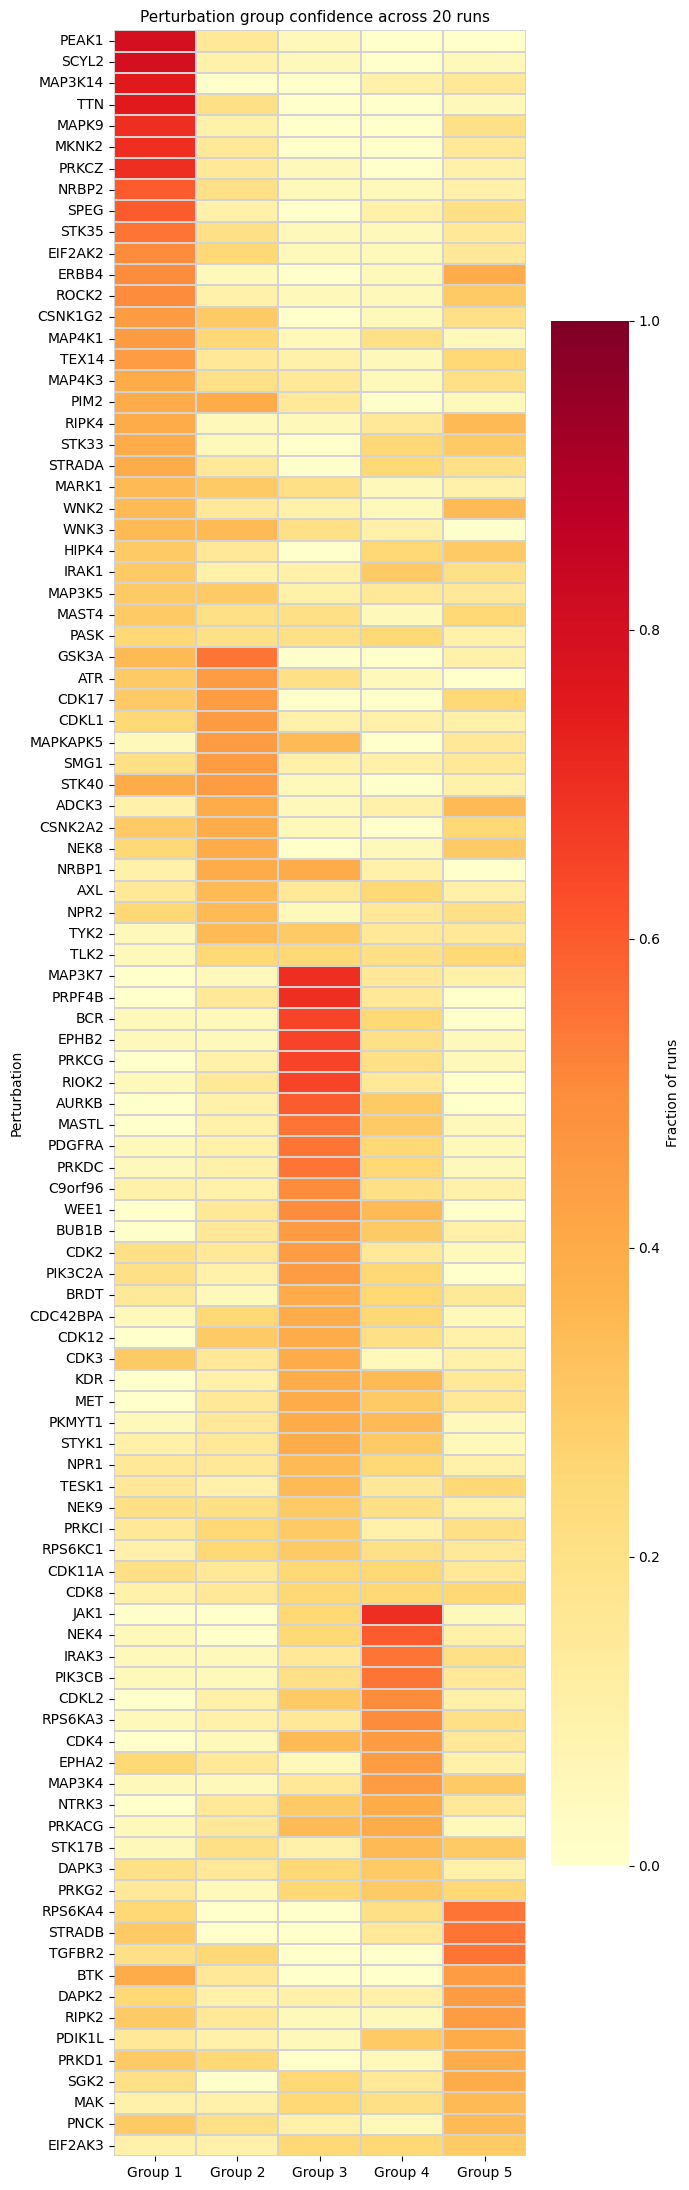

In [39]:
plot_conf = confidence_df[group_cols]

fig, ax = plt.subplots(figsize=(max(5, len(group_cols) * 1.4), max(8, P_n * 0.22)))
sns.heatmap(
    plot_conf, ax=ax,
    cmap='YlOrRd', vmin=0, vmax=1,
    linewidths=0.3, linecolor='lightgray',
    cbar_kws={'label': 'Fraction of runs'},
    annot=(P_n <= 40), fmt='.2f' if P_n <= 40 else '',
)
ax.set_title(
    f'Perturbation group confidence across {N_RUNS} runs  ',
    fontsize=11,
)
ax.set_ylabel('Perturbation')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/confidence_heatmap_k{N_CLUSTERS}.png', bbox_inches='tight', dpi=150)
plt.show()

## Visualisation — per-group confidence bar chart

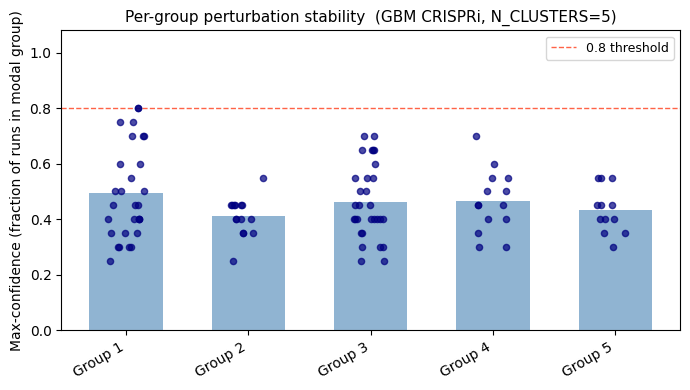

In [40]:
fig, ax = plt.subplots(figsize=(max(6, len(group_cols) * 1.4), 4))

for k, grp in enumerate(group_cols):
    sub  = confidence_df[confidence_df['modal_group'] == grp]
    vals = sub['max_conf'].values
    ax.bar(k, vals.mean() if len(vals) else 0, color='steelblue', alpha=0.6, width=0.6)
    ax.scatter(
        np.full(len(vals), k) + np.random.uniform(-0.15, 0.15, len(vals)),
        vals, color='navy', s=20, zorder=3, alpha=0.7,
    )

ax.set_xticks(range(len(group_cols)))
ax.set_xticklabels(group_cols, rotation=30, ha='right')
ax.set_ylabel('Max-confidence (fraction of runs in modal group)')
ax.set_ylim(0, 1.08)
ax.axhline(0.8, color='tomato', linestyle='--', linewidth=1, label='0.8 threshold')
ax.legend(fontsize=9)
ax.set_title(f'Per-group perturbation stability  (GBM CRISPRi, N_CLUSTERS={N_CLUSTERS})', fontsize=11)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/group_confidence_bars_k{N_CLUSTERS}.png', bbox_inches='tight', dpi=150)
plt.show()

## Visualisation — co-membership heatmap

Sorted by modal reference group so block structure is visible.

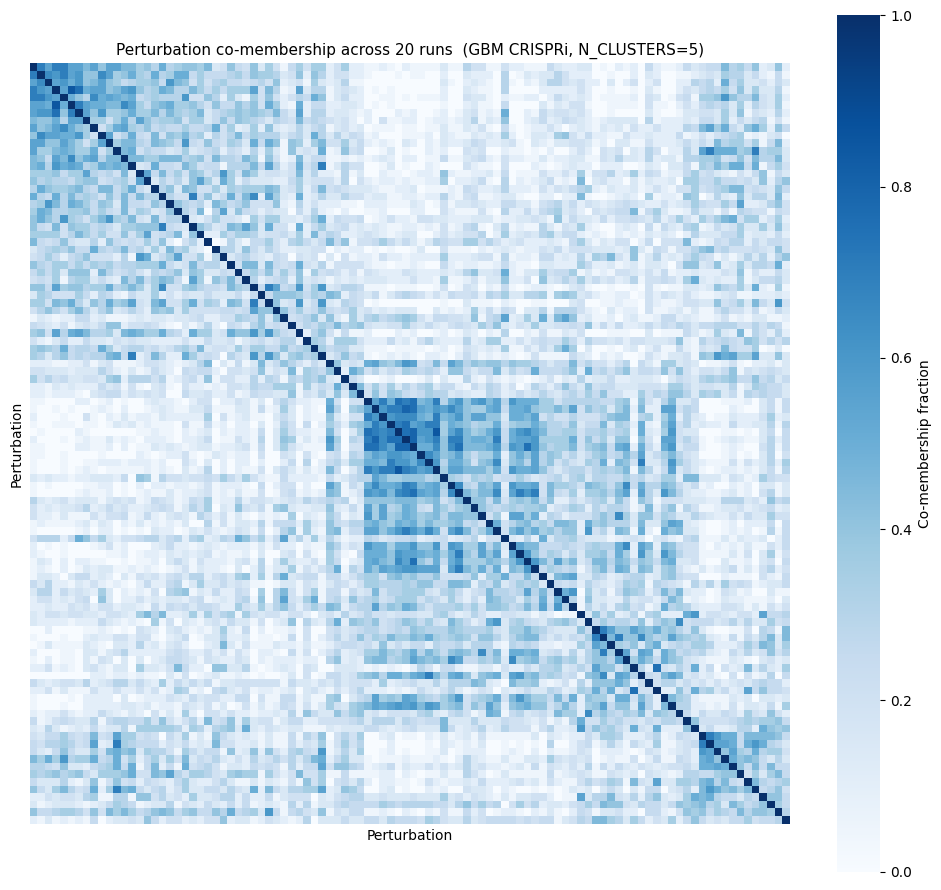

In [41]:
sort_order = confidence_df.index.tolist()
cm_plot    = comembership_df.loc[sort_order, sort_order]

fig, ax = plt.subplots(figsize=(10, 9))
ytick = sort_order if P_n <= 60 else False
sns.heatmap(
    cm_plot, ax=ax,
    cmap='Blues', vmin=0, vmax=1,
    xticklabels=False, yticklabels=ytick,
    cbar_kws={'label': 'Co-membership fraction'},
    square=True,
)
ax.set_title(
    f'Perturbation co-membership across {N_RUNS} runs  '
    f'(GBM CRISPRi, N_CLUSTERS={N_CLUSTERS})',
    fontsize=11,
)
ax.set_xlabel('Perturbation')
ax.set_ylabel('Perturbation')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/comembership_heatmap_k{N_CLUSTERS}.png', bbox_inches='tight', dpi=150)
plt.show()

## Visualisation — pairwise similarity boxplots & heatmaps

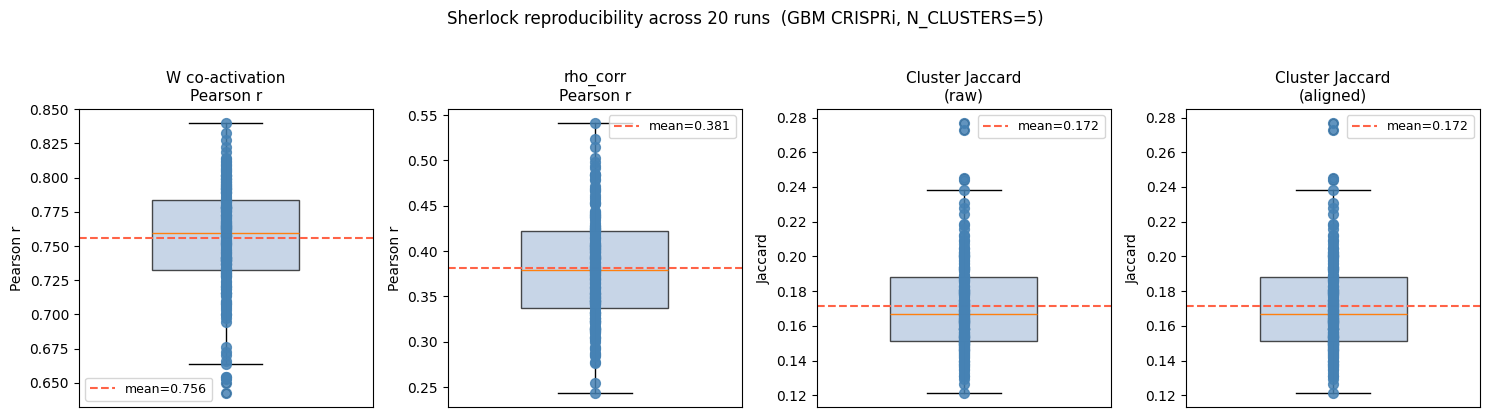

In [42]:
metric_info = [
    (w_corrs,        'W co-activation\nPearson r',  'Pearson r'),
    (cov_corrs,      'rho_corr\nPearson r',          'Pearson r'),
    (jaccard_raw,    'Cluster Jaccard\n(raw)',        'Jaccard'),
    (jaccard_aligned,'Cluster Jaccard\n(aligned)',   'Jaccard'),
]

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, (values, title, ylabel) in zip(axes, metric_info):
    clean = [v for v in values if np.isfinite(v)]
    ax.boxplot(clean, widths=0.5, patch_artist=True,
               boxprops=dict(facecolor='lightsteelblue', alpha=0.7))
    ax.scatter([1]*len(clean), clean, color='steelblue', s=50, zorder=3, alpha=0.85)
    m = np.mean(clean)
    ax.axhline(m, color='tomato', linestyle='--', linewidth=1.5, label=f'mean={m:.3f}')
    ax.set_title(title, fontsize=11)
    ax.set_ylabel(ylabel)
    ax.set_xticks([])
    ax.set_xlim(0.5, 1.5)
    ax.legend(fontsize=9)

fig.suptitle(
    f'Sherlock reproducibility across {N_RUNS} runs  (GBM CRISPRi, N_CLUSTERS={N_CLUSTERS})',
    y=1.03, fontsize=12,
)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/reproducibility_boxplots_k{N_CLUSTERS}.png', bbox_inches='tight')
plt.show()

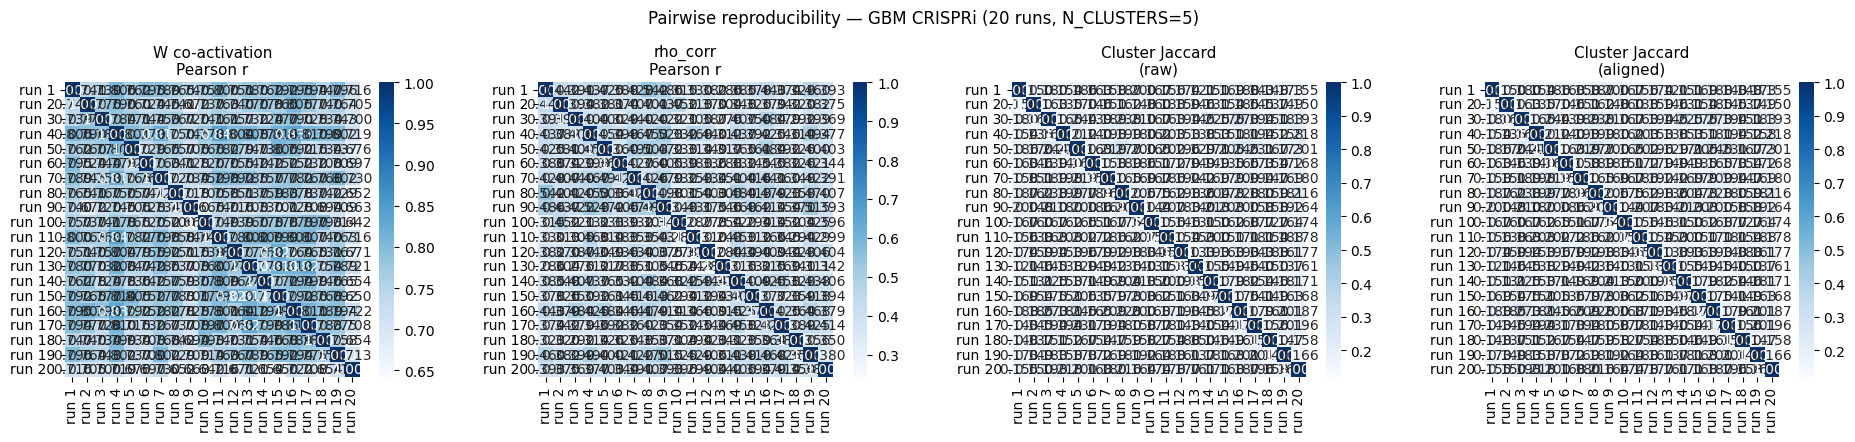

In [43]:
def to_matrix(values, n_runs, pairs):
    M = np.full((n_runs, n_runs), np.nan)
    np.fill_diagonal(M, 1.0)
    for (i, j), v in zip(pairs, values):
        M[i, j] = v
        M[j, i] = v
    return M

W_mat  = to_matrix(w_corrs,        N_RUNS, pairs)
C_mat  = to_matrix(cov_corrs,      N_RUNS, pairs)
Jr_mat = to_matrix(jaccard_raw,    N_RUNS, pairs)
Ja_mat = to_matrix(jaccard_aligned,N_RUNS, pairs)

run_labels = [f"run {k+1}" for k in range(N_RUNS)]
fig, axes = plt.subplots(1, 4, figsize=(19, 4))
for ax, mat, title in zip(
    axes,
    [W_mat, C_mat, Jr_mat, Ja_mat],
    ['W co-activation\nPearson r', 'rho_corr\nPearson r',
     'Cluster Jaccard\n(raw)', 'Cluster Jaccard\n(aligned)'],
):
    off_diag = mat[~np.eye(N_RUNS, dtype=bool)]
    vmin = np.nanmin(off_diag)
    sns.heatmap(
        mat, ax=ax, annot=True, fmt='.3f',
        vmin=vmin, vmax=1.0, cmap='Blues',
        xticklabels=run_labels, yticklabels=run_labels, square=True,
    )
    ax.set_title(title, fontsize=11)

plt.suptitle(
    f'Pairwise reproducibility — GBM CRISPRi ({N_RUNS} runs, N_CLUSTERS={N_CLUSTERS})',
    y=1.03, fontsize=12,
)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/figures/reproducibility_heatmaps_k{N_CLUSTERS}.png', bbox_inches='tight')
plt.show()

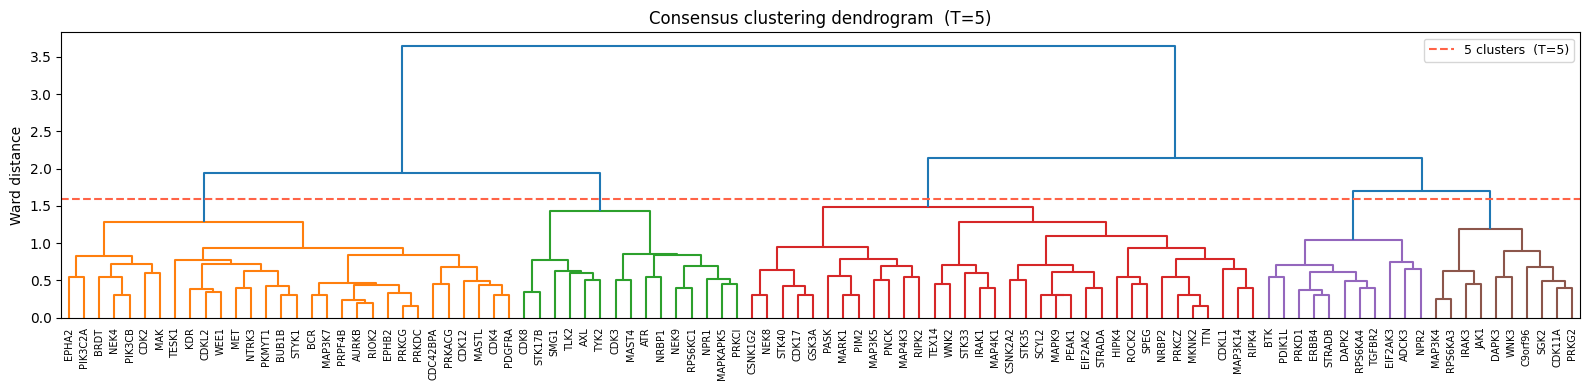

In [48]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import squareform

dist = squareform(1 - comembership, checks=False)
Z    = linkage(dist, method='ward')

# ── specify cut: int → maxclust, float → distance threshold ──────────────────
T = N_CLUSTERS
# T = 0.4   # uncomment and set a float to cut at a specific ward distance
# ─────────────────────────────────────────────────────────────────────────────

if isinstance(T, int):
    consensus_labels = fcluster(Z, t=T, criterion='maxclust')
    cut = (Z[-T, 2] + Z[-T + 1, 2]) / 2
else:
    consensus_labels = fcluster(Z, t=T, criterion='distance')
    cut = T

n_found = len(set(consensus_labels))

fig, ax = plt.subplots(figsize=(16, 4))
dendrogram(Z, labels=all_perts, leaf_rotation=90, leaf_font_size=7,
           color_threshold=cut, ax=ax)
ax.axhline(cut, color='tomato', linestyle='--', linewidth=1.5,
           label=f'{n_found} clusters  (T={T})')
ax.legend(fontsize=9)
ax.set_ylabel('Ward distance')
ax.set_title(f'Consensus clustering dendrogram  (T={T})')
plt.tight_layout()
plt.show()

# Confidence = average co-membership with own consensus cluster
consensus_ng = pd.Series(consensus_labels, index=all_perts, name='group')

conf_rows = []
for p in all_perts:
    g       = consensus_ng[p]
    in_grp  = [q for q in all_perts if consensus_ng[q] == g and q != p]
    out_grp = [q for q in all_perts if consensus_ng[q] != g]
    within  = comembership_df.loc[p, in_grp].mean()  if in_grp  else np.nan
    between = comembership_df.loc[p, out_grp].mean() if out_grp else np.nan
    conf_rows.append({
        'perturbation': p,
        'group':        g,
        'within_comem': within,
        'between_comem': between,
        'confidence':   within - between,
    })

consensus_conf = pd.DataFrame(conf_rows).set_index('perturbation')
consensus_conf = consensus_conf.sort_values(['group', 'confidence'], ascending=[True, False])


## DEGs per perturbation (vs NTC, Wilcoxon)

In [93]:
data_untreated.obs[p_key] == NTC

01D_A01_RT_BC_103_Lig_BC_64-0      True
01D_A01_RT_BC_164_Lig_BC_169-0     True
01D_C01_RT_BC_142_Lig_BC_111-0     True
01D_F01_RT_BC_106_Lig_BC_154-0     True
01D_G01_RT_BC_103_Lig_BC_133-0     True
                                  ...  
12D_H12_RT_BC_185_Lig_BC_78-1     False
12D_H12_RT_BC_187_Lig_BC_162-1    False
12D_H12_RT_BC_187_Lig_BC_186-1    False
12D_H12_RT_BC_189_Lig_BC_185-1    False
12D_H12_RT_BC_192_Lig_BC_155-1    False
Name: pert, Length: 5628, dtype: bool

In [9]:
import warnings

data_untreated = data[data.obs[c_key] == c_ntc_key].copy()
sc.pp.normalize_total(data_untreated, target_sum=1e4)
sc.pp.log1p(data_untreated)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    sc.tl.rank_genes_groups(
        data_untreated,
        groupby=p_key,
        reference=NTC,
        method='wilcoxon',
        key_added='degs',
        pts=True,
    )

degs_df = sc.get.rank_genes_groups_df(data_untreated, group=None, key='degs')
degs_df = degs_df.rename(columns={'group': 'perturbation', 'names': 'gene'})
degs_df = degs_df[degs_df['perturbation'] != NTC].reset_index(drop=True)

SIG_PADJ  = 0.05
SIG_LOGFC = 0.25

all_perts = data_untreated.obs[p_key].unique().tolist()
all_perts = [p for p in all_perts if p != NTC]

sig   = degs_df[(degs_df['pvals_adj'] < SIG_PADJ) & (degs_df['logfoldchanges'].abs() > SIG_LOGFC)]
n_sig = sig.groupby('perturbation').size().rename('n_sig_degs').reindex(all_perts, fill_value=0)

print(f"Condition: {c_key} == {c_ntc_key}  ({data_untreated.n_obs} cells)")
print(f"Significant DEGs  (padj < {SIG_PADJ}, |logFC| > {SIG_LOGFC}):")
print(f"  Perturbations with ≥1 DEG : {(n_sig > 0).sum()} / {len(n_sig)}")
print(f"  Median DEGs per pert      : {n_sig.median():.0f}")
print(f"  Max DEGs                  : {n_sig.max()}  ({n_sig.idxmax()})")
print()
print(n_sig.sort_values(ascending=False).to_string())


Condition: treatment == 0.0  (5628 cells)
Significant DEGs  (padj < 0.05, |logFC| > 0.25):
  Perturbations with ≥1 DEG : 0 / 100
  Median DEGs per pert      : 0
  Max DEGs                  : 0  (RPS6KA4)

perturbation
RPS6KA4     0
PDIK1L      0
TTN         0
RPS6KC1     0
HIPK4       0
DAPK3       0
NEK9        0
ADCK3       0
NRBP2       0
CDK3        0
PRKCG       0
RPS6KA3     0
MAPK9       0
EIF2AK3     0
NEK8        0
MAP3K4      0
GSK3A       0
TGFBR2      0
NRBP1       0
SGK2        0
NTRK3       0
JAK1        0
MKNK2       0
RIPK2       0
NEK4        0
SMG1        0
CDKL1       0
WNK2        0
STK33       0
SCYL2       0
ROCK2       0
DAPK2       0
TLK2        0
SPEG        0
CSNK2A2     0
CDK12       0
MAP4K1      0
TEX14       0
NPR1        0
STK17B      0
STRADA      0
WEE1        0
STRADB      0
IRAK3       0
PRKCI       0
MAP3K7      0
MAP4K3      0
IRAK1       0
PDGFRA      0
EIF2AK2     0
PASK        0
PIM2        0
AXL         0
PRKCZ       0
PIK3C2A     0
MAK         

Median absolute shift from NTC mean (per gene):
  Perturbations : 0.1109
  NTC null      : 0.0763  (random subsamples of 54 NTC cells)


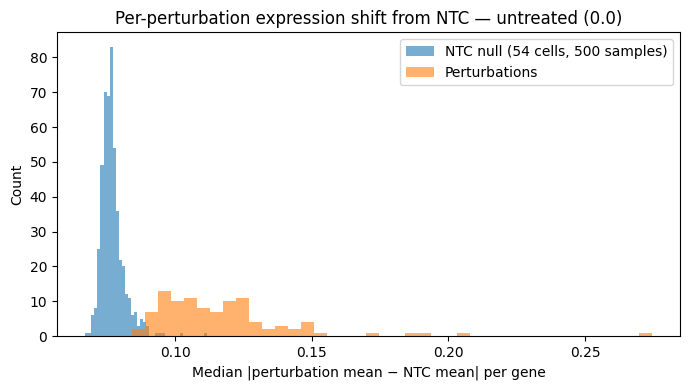

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

X = data_untreated.X
if not isinstance(X, np.ndarray):
    X = X.toarray()

perts_obs = data_untreated.obs[p_key]
ntc_cells = X[(perts_obs == NTC).values]
ntc_mean  = ntc_cells.mean(axis=0)

all_perts  = [p for p in perts_obs.unique() if p != NTC]
shifts, pert_sizes = {}, {}
for p in all_perts:
    mask = (perts_obs == p).values
    if mask.sum() == 0:
        continue
    shifts[p]     = np.median(np.abs(X[mask].mean(axis=0) - ntc_mean))
    pert_sizes[p] = mask.sum()

shift_series = pd.Series(shifts)
median_n     = int(np.median(list(pert_sizes.values())))

rng       = np.random.default_rng(42)
null_shift = [
    np.median(np.abs(ntc_cells[rng.choice(len(ntc_cells), median_n, replace=False)].mean(axis=0) - ntc_mean))
    for _ in range(500)
]

print(f"Median absolute shift from NTC mean (per gene):")
print(f"  Perturbations : {shift_series.median():.4f}")
print(f"  NTC null      : {np.median(null_shift):.4f}  (random subsamples of {median_n} NTC cells)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(null_shift,   bins=40, alpha=0.6, label=f'NTC null ({median_n} cells, 500 samples)')
ax.hist(shift_series, bins=40, alpha=0.6, label='Perturbations')
ax.set_xlabel('Median |perturbation mean − NTC mean| per gene')
ax.set_ylabel('Count')
ax.set_title(f'Per-perturbation expression shift from NTC — untreated ({c_ntc_key})')
ax.legend()
plt.tight_layout()
plt.show()


In [60]:
consensus_conf[consensus_conf.index =='PDGFRA']

,group,within_comem,between_comem,confidence
perturbation,,,,
PDGFRA,1,0.472414,0.126429,0.345985


In [58]:
consensus_conf[consensus_conf['group'] == 1].sort_values('perturbation')

,group,within_comem,between_comem,confidence
perturbation,,,,
AURKB,1,0.560345,0.140000,0.420345
BCR,1,0.491379,0.123571,0.367808
BRDT,1,0.417241,0.149286,0.267956
BUB1B,1,0.534483,0.120714,0.413768
CDC42BPA,1,0.375862,0.160000,0.215862
CDK12,1,0.467241,0.134286,0.332956
CDK2,1,0.374138,0.175714,0.198424
CDK4,1,0.458621,0.118571,0.340049
CDKL2,1,0.417241,0.144286,0.272956
